<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/main/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [11]:
import pandas as pd

df = pd.read_csv("CS105_data.csv")

column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency

cols = ['AI Chatbot Usage', 'Agreement']
df = pd.read_csv('CS105_data_clean.csv')[cols].dropna()

crosstab = pd.crosstab(df[cols[0]], df[cols[1]])

**Core Question: How does a student's frequency of using AI for their coursework affect their confidence in learning and trusting their own abilities?**

**Independent Variable: AI Usage** --> Please rate how much you consult each source when you're having trouble with coursework?(measured on a scale from 0 = not at all, to 5 = all the time)

**Dependent Variable: Agreement** --> Rate your level of agreement: Using AI does not interfere with my confidence in original work of my own.(measured on a scale from 0 = Strongly Disagree, to 5 = Strongly Agree)

**To visualize the relationship between AI Usage and Confidence, we used two graphs:**

**Boxplot:** This illustrates the median, spread, and distribution of confidence scores across each level of AI usage. It helps us identify if there is a correlation between higher usage categories and higher or lower confidence.

**Heatmap:** Since both variables are categorical, many data points overlap. A heatmap of the matrix shows the exact concentration of student answers at every point.

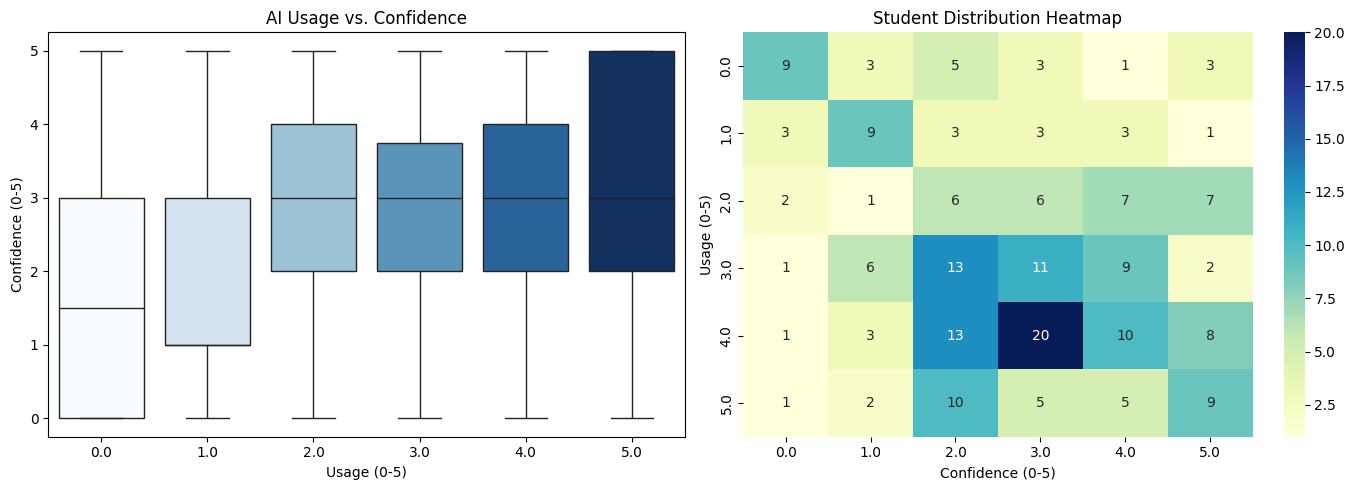

In [18]:
# 2. Create a 1x2 grid for plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Box Plot
sns.boxplot(
    data=df, x=cols[0], y=cols[1],
    hue=cols[0], palette='Blues', legend=False, ax=ax[0]
)
ax[0].set(title='AI Usage vs. Confidence', xlabel='Usage (0-5)', ylabel='Confidence (0-5)')

# Graph B: Heatmap
sns.heatmap(crosstab, annot=True, cmap='YlGnBu', fmt='d', ax=ax[1])
ax[1].set(title='Student Distribution Heatmap', xlabel='Confidence (0-5)', ylabel='Usage (0-5)')

plt.tight_layout()
plt.show()

**Null Hypothesis:** There is no correlation between student's usage frequency of AI for coursework and their agreement that AI doesn't impact their confidence in their own work.

**Alternative Hypothesis:** There is a statistically significant correlation between the frequency of a student's use of AI and their agreement that AI doesn't impact their confidence.

**Spearman's Rank Correlation:** Since both variables are ordinal, Spearman's correlation is the best test to measure the strength of the relationship between the two variables

**Chi-Squared Test of Independence:** This test determines if there is a significant association between two categorical variables. We are testing to see if the "Agreement" rating is independent of the "AI" rating.

In [20]:
# 3. statistics
r, p_spear = spearmanr(df[cols[0]], df[cols[1]])
chi2, p_chi2, dof, _ = chi2_contingency(crosstab)

# Print results
print("--- Statistical Results ---")
print(f"Spearman Correlation: r = {r:.3f}, p = {p_spear:.5f}")
print(f"Chi-Squared Test:     X² = {chi2:.3f}, p = {p_chi2:.5f}, dof = {dof}")

--- Statistical Results ---
Spearman Correlation: r = 0.268, p = 0.00011
Chi-Squared Test:     X² = 75.217, p = 0.00000, dof = 25


### **Results**
The Spearmant Correlation yielded a statistic of r being approximately equal to 0.268, with a p-value of 0.00011.

The Chi-Squared Test yielded a statistico of x^2 being approximately equal to 75.217 with a p-value of 0.00000.

Becaause the p-values for both tests are well below the standard level of 0.05, **we reject the null hypothesis.**

##**Conclusion**
Looking back at our core question--How does AI usage affect confidence in original work?--the data shows a statisticaly significant positive correlation.

The results contradict the assumption that relying on AI ruins a student's trust in their own work. Instead, students that consult AI more often tend to report **higher levels of agreement** that AI doesn't impac their confidence in their own work. This suggests that frequent AI users may view technology as a supportive tool rather than a crutch that replaces their own abilities.